<a href="https://www.kaggle.com/code/cartelsmith/how-to-cross-validation-lr-prediction?scriptVersionId=336586356" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "student-lifestyle-and-stress-dataset.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "sridevilavanyacse/student-lifestyle-and-stress-prediction-dataset",
  file_path,
  # Provide any additional arguments like 
  # sql_query or pandas_kwargs. See the 
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns
import matplotlib.pyplot as plt

/tmp/ipykernel_58/2550196839.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


# Dataset General Info

In [2]:
df.info()
print('--'*50)
df.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25500 entries, 0 to 25499
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Student_Type        24248 non-null  object 
 1   Sleep_Hours         24167 non-null  float64
 2   Study_Hours         24223 non-null  float64
 3   Social_Media_Hours  24188 non-null  float64
 4   Attendance          24195 non-null  float64
 5   Exam_Pressure       24230 non-null  float64
 6   Family_Support      24209 non-null  float64
 7   Month               24186 non-null  float64
 8   Stress_Level        25500 non-null  int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 1.8+ MB
----------------------------------------------------------------------------------------------------


,Student_Type,Sleep_Hours,Study_Hours,Social_Media_Hours,Attendance,Exam_Pressure,Family_Support,Month,Stress_Level
0,school,6.868702,1.711722,3.176942,NaN,8.0,7.0,2.0,1
1,school,8.519088,3.251084,3.880787,93.978465,6.0,4.0,3.0,1
2,college,4.498770,6.306885,2.936172,64.421253,7.0,1.0,12.0,1
3,school,8.591223,2.384922,5.222832,81.868960,2.0,7.0,7.0,0
4,college,5.329293,9.345179,7.815869,85.847982,5.0,6.0,10.0,1
5,college,4.914849,NaN,2.141137,85.144095,3.0,5.0,5.0,0
6,college,6.621709,5.261762,4.879102,NaN,4.0,7.0,7.0,0
7,college,6.357065,2.827955,6.198479,74.180341,7.0,8.0,6.0,0
8,college,8.085219,5.043731,4.660604,89.564367,3.0,2.0,7.0,0
9,college,4.627502,4.743084,5.579822,95.794315,5.0,5.0,10.0,0


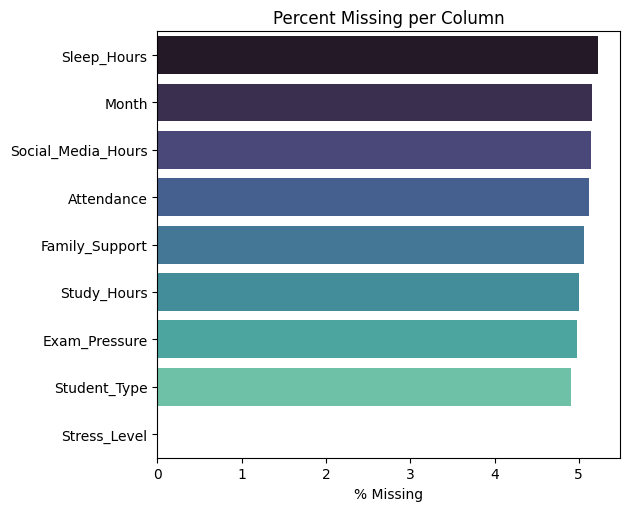

In [3]:
# Missing Values
missing_pct = ((df.isna().sum()/25500)*100)
missing_pct.round(1).head(15)

sns.barplot(missing_pct.sort_values(ascending=False), palette='mako', orient='h')

plt.tight_layout()
plt.xlabel('% Missing')
plt.title('Percent Missing per Column')
plt.show();

In [4]:
print(df.nunique())
df['Student_Type'] = df['Student_Type'].astype('category')


Student_Type              3
Sleep_Hours           23695
Study_Hours           24223
Social_Media_Hours    23713
Attendance            23576
Exam_Pressure            10
Family_Support           10
Month                    12
Stress_Level              2
dtype: int64


# Preliminary Data Overview (Light EDA)

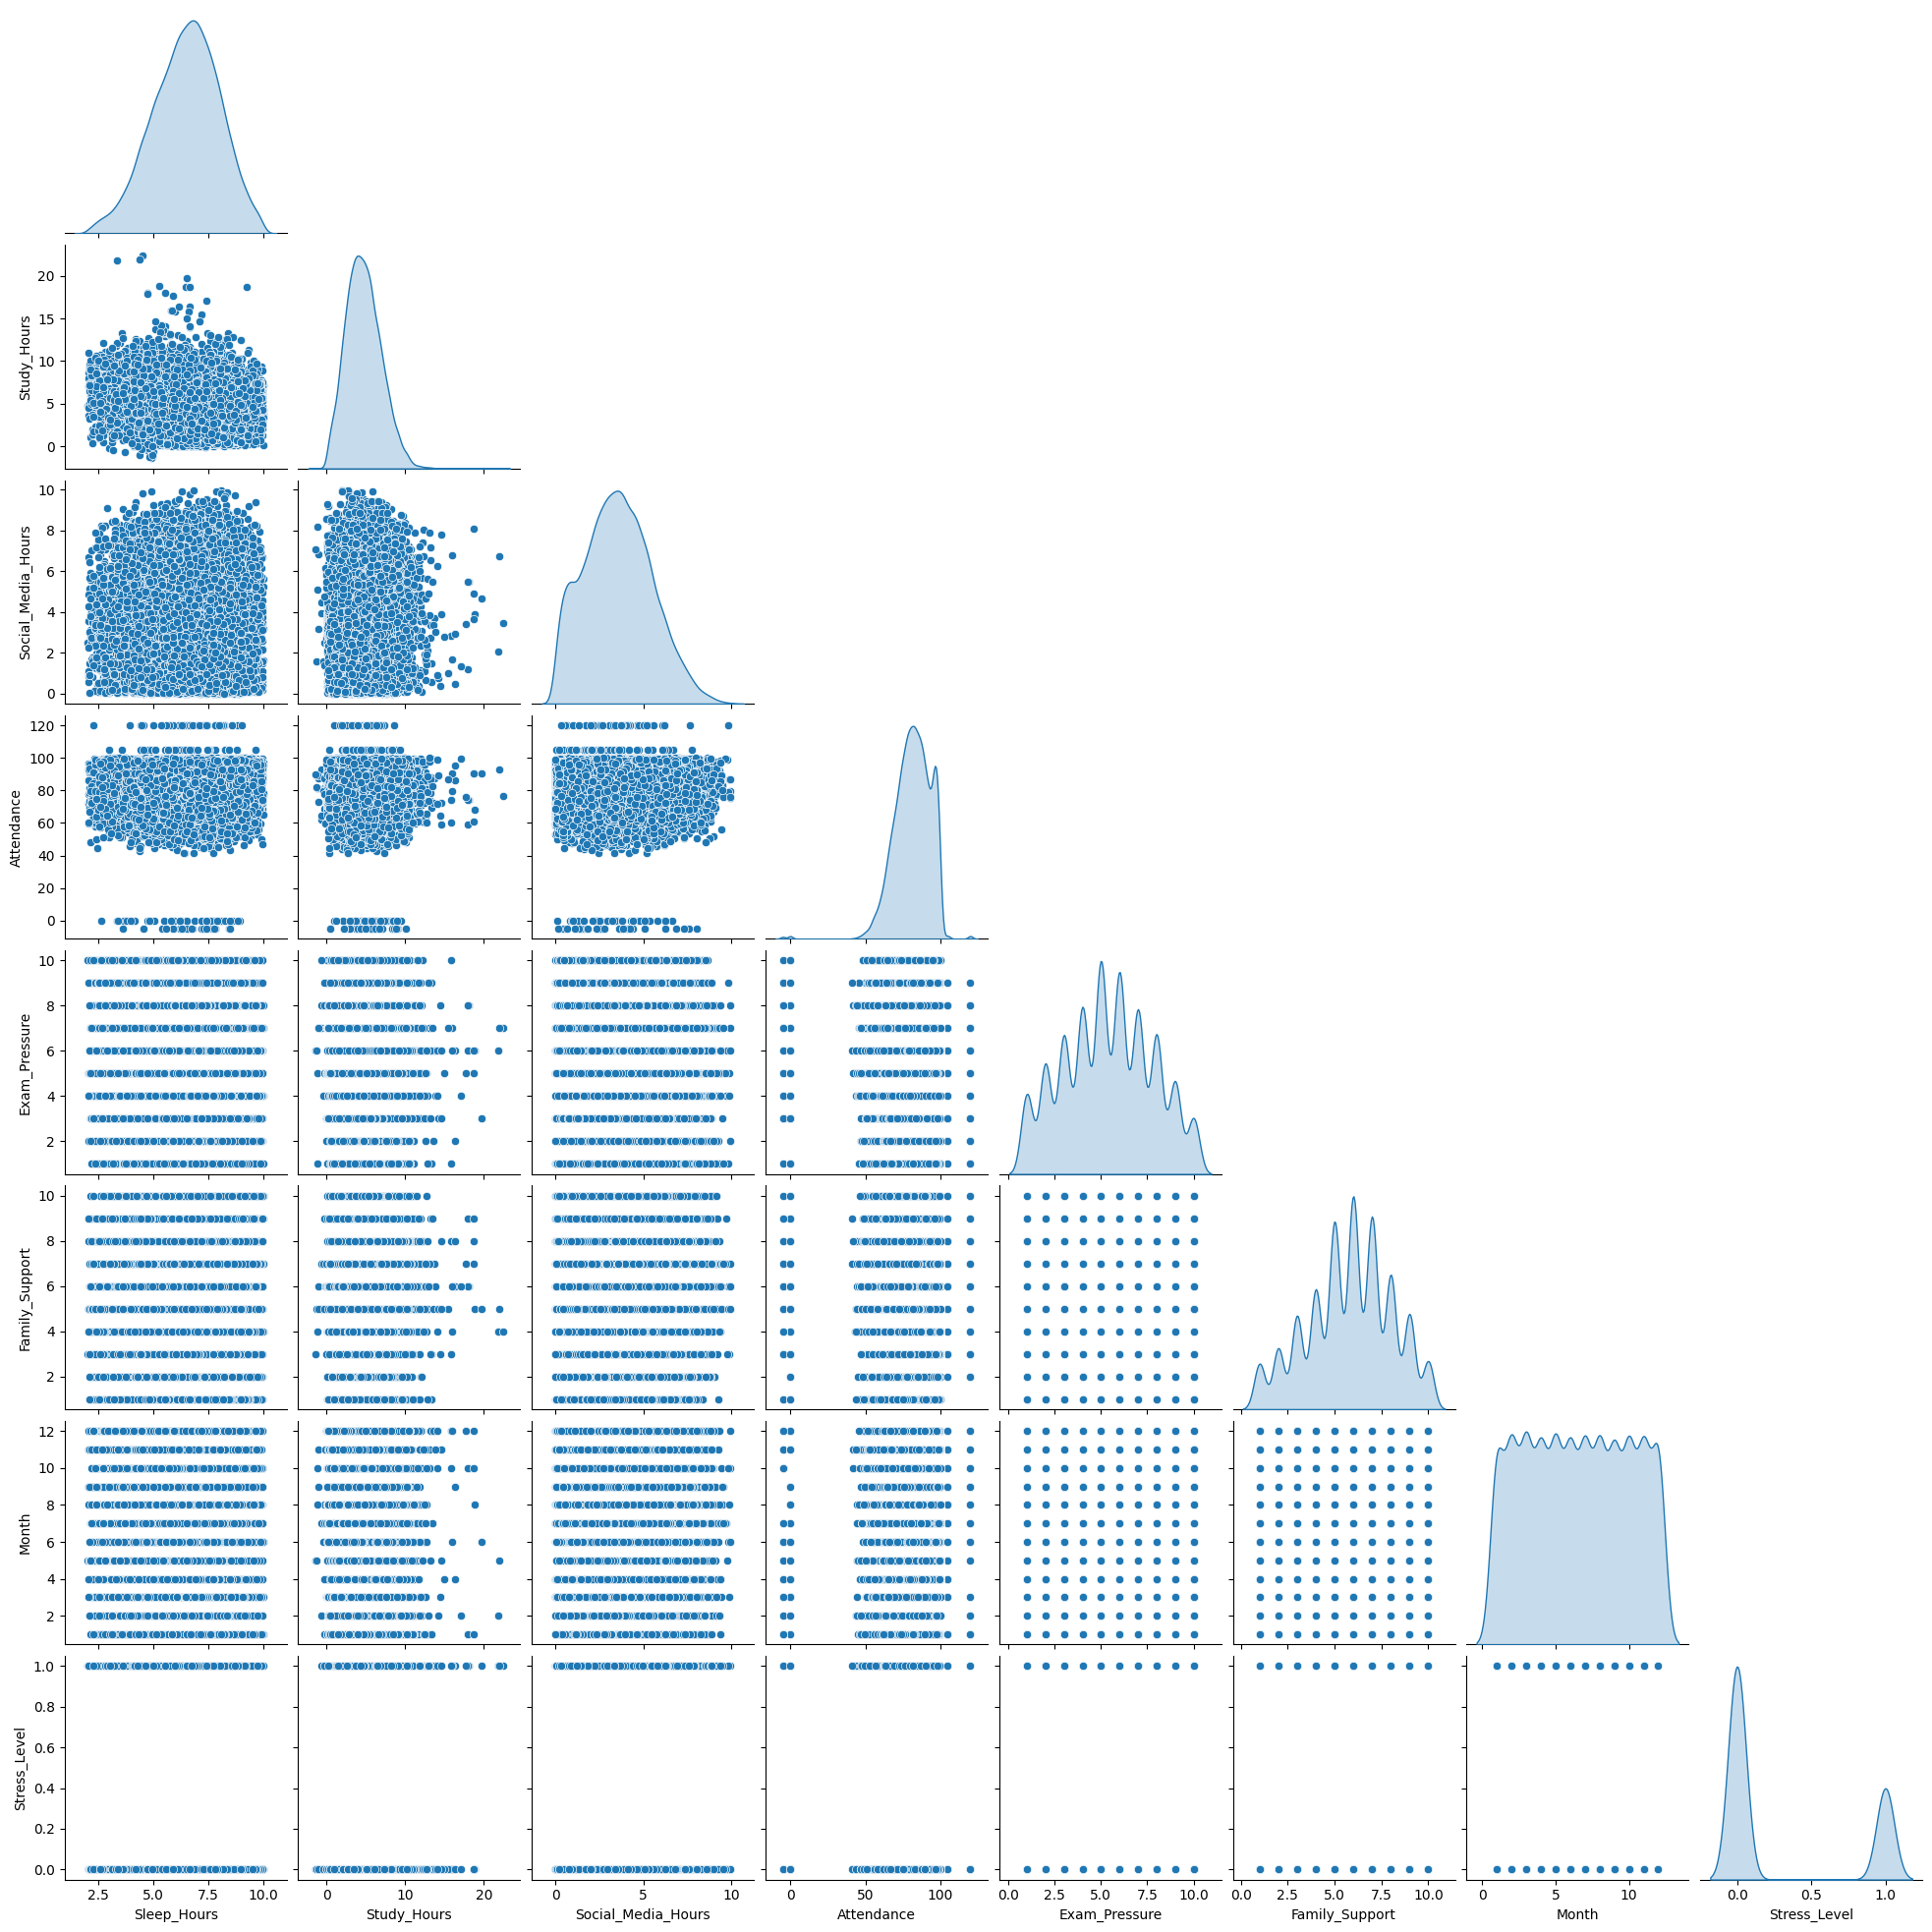

In [5]:
# Viewing distributions of numeric columns
num_cols = df.select_dtypes('number')


sns.pairplot(num_cols,diag_kind='kde',corner=True, dropna=True);


# Machine Learning: Model Construction

In [6]:
# Split into training and validation sets
from sklearn.model_selection import train_test_split

features = df.drop(columns='Stress_Level')
target = df['Stress_Level']

Xtrain,xtest, Ytrain,ytest = train_test_split(features, target, random_state=12, train_size=.8, stratify=target)

In [7]:
# Preprocess Data
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline

num_cols = features.select_dtypes(include='number').columns.tolist()
cat_cols = features.select_dtypes(exclude='number').columns.tolist()


print(f'🔢The numeric columns are:\n{num_cols}')
print(f'\n\n🎏The categorical columns are:\n{cat_cols}')

# Building Transformers

num_transformer = make_pipeline(KNNImputer(n_neighbors=3))
categorical_transformer = make_pipeline(SimpleImputer(strategy='most_frequent'), OneHotEncoder())


# Building Preprocessor
preprocessor = ColumnTransformer([('num',num_transformer,num_cols),
                                  ('categories', categorical_transformer,cat_cols)
                                ])



🔢The numeric columns are:
['Sleep_Hours', 'Study_Hours', 'Social_Media_Hours', 'Attendance', 'Exam_Pressure', 'Family_Support', 'Month']


🎏The categorical columns are:
['Student_Type']


In [8]:
# Build Model
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model_pipeline = make_pipeline(preprocessor, model)



In [9]:
# Evaluate Model
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_validate, cross_val_score
 
cv_score = cross_val_score(model_pipeline,Xtrain,Ytrain, cv=4, verbose=3)
print(f'\nThe cross validation score for each fold is: {cv_score}.\nAnd the avg score per fold is: {cv_score.mean():.2f}.')


[CV] END ................................ score: (test=0.812) total time=   5.1s
[CV] END ................................ score: (test=0.821) total time=   5.0s
[CV] END ................................ score: (test=0.808) total time=   5.0s
[CV] END ................................ score: (test=0.810) total time=   5.0s

The cross validation score for each fold is: [0.81176471 0.82098039 0.80764706 0.80960784].
And the avg score per fold is: 0.81.


[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:   20.1s finished


# Machine Learning: Model Iteration and Improvement

In [10]:
# Finding the ideal hyperparameters for this model using GridsearchCV
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

#help(LogisticRegression) |Uncomment to see all params

param_sweep = [
    {
        'logisticregression__penalty': ['l2', None],
        'logisticregression__solver': ['lbfgs', 'newton-cg', 'newton-cholesky', 'sag'],
        
    },
    {
        'logisticregression__penalty': ['l1', 'l2'],
        'logisticregression__solver': ['liblinear'],
        
    },
    {
        'logisticregression__penalty': ['l1', 'l2', 'elasticnet', None],
        'logisticregression__solver': ['saga'],
        
    }
]

grid_search = RandomizedSearchCV(model_pipeline, param_distributions=param_sweep,
                                 n_iter = 25, cv=4, verbose=1)

grid_search.fit(Xtrain, Ytrain)

Fitting 4 folds for each of 14 candidates, totalling 56 fits


RandomizedSearchCV(cv=4,
                   estimator=Pipeline(steps=[('columntransformer',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('knnimputer',
                                                                                                KNNImputer(n_neighbors=3))]),
                                                                               ['Sleep_Hours',
                                                                                'Study_Hours',
                                                                                'Social_Media_Hours',
                                                                                'Attendance',
                                                                                'Exam_Pressure',
                                                                                'Family_Support',
                                                                                'Month']),
                                                                              ('categories',
                                                                               Pipeline(steps=[('simpleimputer',
                                                                                                SimpleImputer(strategy='most...
                                              LogisticRegression())]),
                   n_iter=25,
                   param_distributions=[{'logisticregression__penalty': ['l2',
                                                                         None],
                                         'logisticregression__solver': ['lbfgs',
                                                                        'newton-cg',
                                                                        'newton-cholesky',
                                                                        'sag']},
                                        {'logisticregression__penalty': ['l1',
                                                                         'l2'],
                                         'logisticregression__solver': ['liblinear']},
                                        {'logisticregression__penalty': ['l1',
                                                                         'l2',
                                                                         'elasticnet',
                                                                         None],
                                         'logisticregression__solver': ['saga']}],
                   verbose=1)

🥁🥁🥁...And the best parameters for this model are:
 {'logisticregression__solver': 'newton-cholesky', 'logisticregression__penalty': None}


Best Cross-Validated Accuracy: 0.81 




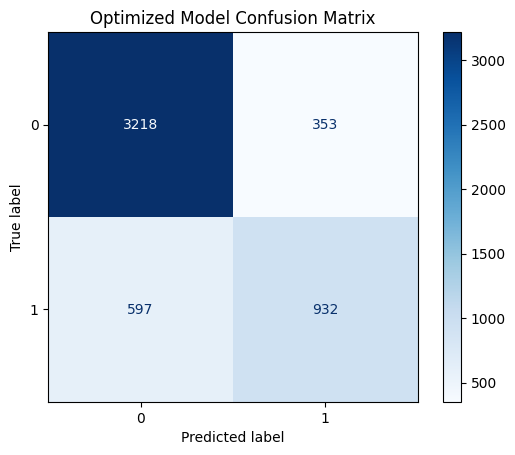

In [11]:
# Evaluating the new optimized model
from sklearn.metrics import ConfusionMatrixDisplay

best_model = grid_search.best_estimator_

print(f'🥁🥁🥁...And the best parameters for this model are:\n {grid_search.best_params_}')
print(f"\n\nBest Cross-Validated Accuracy: {grid_search.best_score_:.2f} \n\n")

# Vizualizing performance using the BEST model
best_predictions = best_model.predict(xtest)

# Fixed Confusion Matrix plotting
disp = ConfusionMatrixDisplay.from_predictions(ytest, best_predictions, cmap='Blues')
plt.title("Optimized Model Confusion Matrix")
plt.show()